In [23]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
base_path = Path("/content/drive/MyDrive/Notebooks") # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [25]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [26]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

Z poprzedniego zadania (EDA) wynika, że przydatne będą cechy: Title, FamilySize, IsAlone, HasCabin, Deck — wszystkie pokazały widoczną zależność ze Survived na wykresach. Braki w Age, Fare i Embarked trzeba uzupełnić przed treningiem, a Name, Ticket i Cabin jako surowy tekst nie nadają się do modelu.

In [27]:
def prepare_data(df):
    df = df.copy()
    df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')
    title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
    df['Title'] = df['Title'].replace(title_mapping)
    rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    df['Deck'] = df['Cabin'].str[0].fillna('U')

    df['Age'] = df.groupby(['Title', 'Pclass'], observed=True)['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df.groupby('Pclass', observed=True)['Fare'].transform(lambda x: x.fillna(x.median()))

    df = df.drop(columns=['Cabin', 'Name', 'Ticket'])
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df = pd.get_dummies(df, columns=['Embarked', 'Title', 'Deck'], dtype=int)
    return df

titanic_df = prepare_data(titanic_df)
titanic_df.isna().sum().sum()

np.int64(0)

To ta sama funkcja czyszcząca co w poprzednim zadaniu - jedna funkcja, żeby nie przepisywać całego notebooka od nowa.

In [28]:
X = titanic_df.drop(columns='Survived')
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(712, 26) (179, 26)


Podział na zbiór treningowy (80%) i testowy (20%) jest robiony przed uzupełnianiem braków i skalowaniem - dzięki temu żadna statystyka ze zbioru testowego nie przecieka do treningu. stratify=y pilnuje, żeby proporcja ocalałych/zmarłych była taka sama w train i test. random_state daje powtarzalność wyniku.

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaler jest dopasowany tylko na train, na test robimy sam transform - inaczej byłby to wyciek danych. Standaryzacja jest ważna dla KNN (liczy odległości), drzewu jest obojętna.

In [30]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    print(name, "| acc train:", round(acc_train, 3), "| acc test:", round(acc_test, 3), "| f1 test:", round(f1_test, 3))
    return {'name': name, 'acc_train': acc_train, 'acc_test': acc_test, 'f1_test': f1_test}

results = []

Accuracy samo w sobie nie wystarczy, bo klasy nie są równe (ok. 62/38) - model zgadujący samo "zginął" miałby już 62% accuracy. F1 pokazuje, czy model faktycznie rozpoznaje osoby, które przeżyły.

In [31]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
results.append(evaluate_model(dummy, X_train, y_train, X_test, y_test, 'Dummy'))

Dummy | acc train: 0.617 | acc test: 0.615 | f1 test: 0.0


Dummy zawsze zgaduje klasę większościową. To jakby punkt odniesienia - każdy model musi wypaść od niego lepiej.

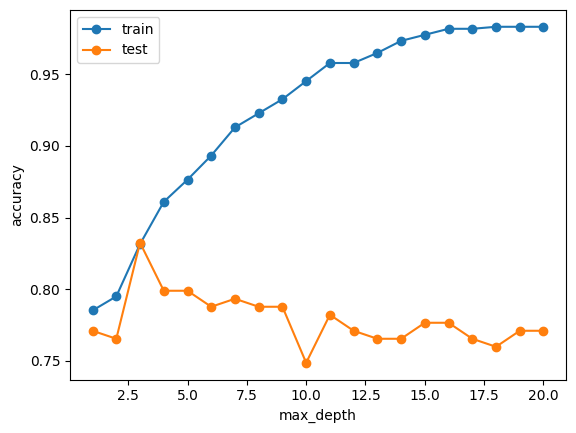

In [32]:
depths = range(1, 21)
train_scores, test_scores = [], []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, tree.predict(X_test)))

plt.plot(depths, train_scores, marker='o', label='train')
plt.plot(depths, test_scores, marker='o', label='test')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.legend()
plt.show()

Im głębsze drzewo, tym lepiej pamięta trening, ale test w pewnym momencie przestaje rosnąć - to jest przeuczenie.

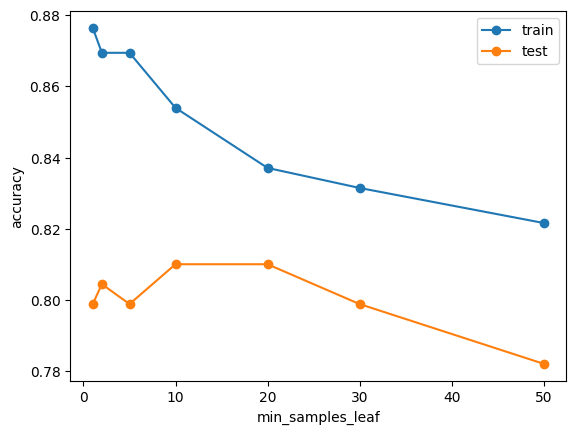

In [33]:
leaf_sizes = [1, 2, 5, 10, 20, 30, 50]
train_scores2, test_scores2 = [], []

for leaf in leaf_sizes:
    tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=leaf, random_state=42)
    tree.fit(X_train, y_train)
    train_scores2.append(accuracy_score(y_train, tree.predict(X_train)))
    test_scores2.append(accuracy_score(y_test, tree.predict(X_test)))

plt.plot(leaf_sizes, train_scores2, marker='o', label='train')
plt.plot(leaf_sizes, test_scores2, marker='o', label='test')
plt.xlabel('min_samples_leaf')
plt.ylabel('accuracy')
plt.legend()
plt.show()

min_samples_leaf to druga blokada przeciw przeuczeniu - im większa, tym drzewo musi mieć więcej "dowodów", żeby zrobić podział. Za duża wartość zaczyna psuć wynik na obu zbiorach naraz.

In [34]:
final_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42)
final_tree.fit(X_train, y_train)
results.append(evaluate_model(final_tree, X_train, y_train, X_test, y_test, 'Tree'))

Tree | acc train: 0.826 | acc test: 0.816 | f1 test: 0.756


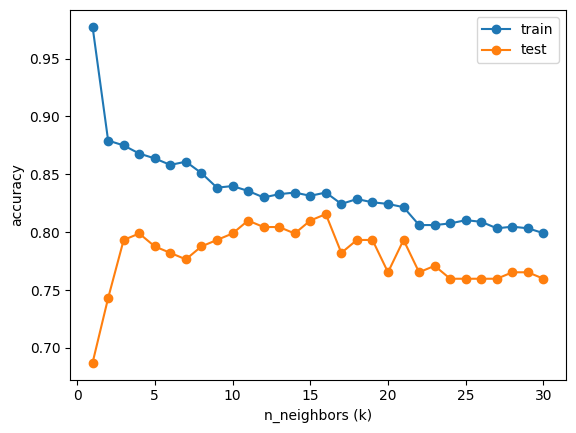

In [35]:
k_values = range(1, 31)
train_scores3, test_scores3 = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores3.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores3.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.plot(list(k_values), train_scores3, marker='o', label='train')
plt.plot(list(k_values), test_scores3, marker='o', label='test')
plt.xlabel('n_neighbors (k)')
plt.ylabel('accuracy')
plt.legend()
plt.show()

KNN patrzy na k najbliższych sąsiadów danego punktu i głosuje, która klasa u nich przeważa. Małe k = model podpiera się pojedynczymi punktami i przeucza się. Duże k = uśrednia zbyt wiele i zaczyna niedouczać.

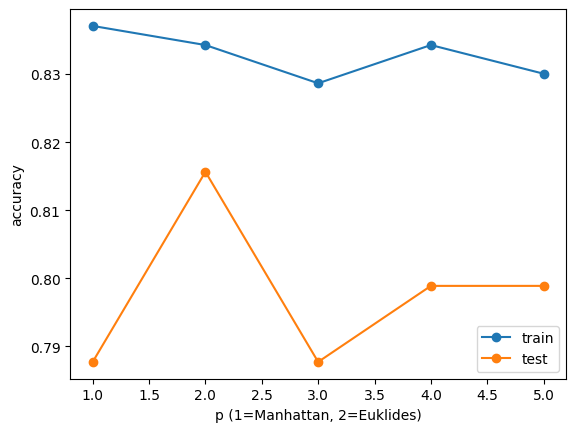

In [36]:
p_values = [1, 2, 3, 4, 5]
train_scores4, test_scores4 = [], []

for p in p_values:
    knn = KNeighborsClassifier(n_neighbors=16, p=p)
    knn.fit(X_train_scaled, y_train)
    train_scores4.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores4.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.plot(p_values, train_scores4, marker='o', label='train')
plt.plot(p_values, test_scores4, marker='o', label='test')
plt.xlabel('p (1=Manhattan, 2=Euklides)')
plt.ylabel('accuracy')
plt.legend()
plt.show()

p zmienia sposób liczenia odległości między punktami. Widoczna różnica, ale nie każdy hiperparametr musi mocno zmieniać wynik.

In [37]:
final_knn = KNeighborsClassifier(n_neighbors=16, p=2)
final_knn.fit(X_train_scaled, y_train)
results.append(evaluate_model(final_knn, X_train_scaled, y_train, X_test_scaled, y_test, 'KNN'))

KNN | acc train: 0.834 | acc test: 0.816 | f1 test: 0.748


In [38]:
results_df = pd.DataFrame(results)
results_df

,name,acc_train,acc_test,f1_test
0,Dummy,0.616573,0.614525,0.000000
1,Tree,0.825843,0.815642,0.755556
2,KNN,0.834270,0.815642,0.748092


Zebrane wyniki wszystkich trzech modeli (Dummy, Tree, KNN) w jedną tabelkę do porównania.

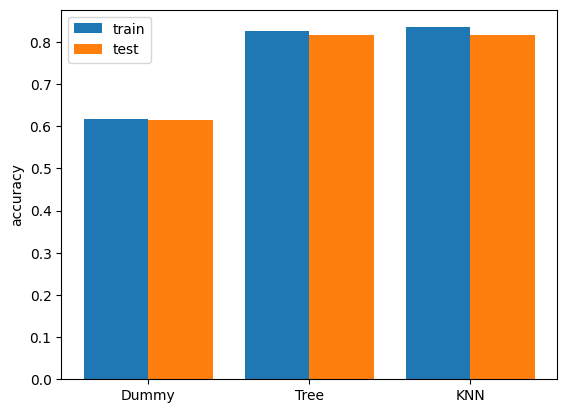

In [39]:
plt.bar(results_df['name'], results_df['acc_train'], width=-0.4, align='edge', label='train')
plt.bar(results_df['name'], results_df['acc_test'], width=0.4, align='edge', label='test')
plt.ylabel('accuracy')
plt.legend()
plt.show()

Wykres słupkowy pokazuje wszystko na raz: model bije Dummy'ego, train/test są blisko siebie (blisko = brak przeuczenia).

Podsumowanie:

*   Dummy zawsze zgaduje "zginął" i ma F1=0 dla klasy "przeżył" - to dolny próg
*   Drzewo i KNN wyraźnie biją Dummy'ego na accuracy i F1 - to znaczy, że faktycznie się czegoś nauczyły.
*   Dobry wynik to taki, gdzie accuracy train i test są blisko siebie.